# Sales Analysis — Data Science Month 1
### CloudExify Summer Internship 2026

**Goal:** Explore the raw transaction data, clean it, and understand overall sales
patterns before moving on to customer segmentation (`customer_segmentation.ipynb`).

This notebook covers:
1. Data loading and cleaning
2. Exploratory Data Analysis (EDA)
3. Statistical analysis (revenue, trends, category performance)
4. Data visualization


## 1. Load and Inspect the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('sample_data/customer_transactions.csv')
print("Shape:", df.shape)
df.head()


Shape: (2624, 5)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  2624 non-null   str    
 1   CustomerID     2624 non-null   str    
 2   Date           2624 non-null   str    
 3   Amount         2624 non-null   float64
 4   Category       2624 non-null   str    
dtypes: float64(1), str(4)
memory usage: 102.6 KB


In [5]:
df.describe(include='all')


## 2. Data Cleaning

Steps: parse dates, check for missing values / duplicates, and remove any invalid
records (e.g. non-positive amounts).

In [7]:
# Parse dates
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check duplicate transactions
print("\nDuplicate rows:", df.duplicated().duplicated().sum())


Missing values per column:
TransactionID    0
CustomerID       0
Date             0
Amount           0
Category         0
dtype: int64

Duplicate rows: 2623


In [8]:
# Remove invalid rows (negative or zero amounts), if any
before = len(df)
df = df[df['Amount'] > 0].copy()
after = len(df)
print(f"Removed {before - after} invalid rows. Remaining: {after}")

df = df.sort_values('Date').reset_index(drop=True)
df.head()


Removed 0 invalid rows. Remaining: 2624


## 3. Exploratory Data Analysis

In [10]:
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total transactions: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Total revenue: Rs {df['Amount'].sum():,.2f}")
print(f"Average transaction value: Rs {df['Amount'].mean():,.2f}")
print(f"Median transaction value: Rs {df['Amount'].median():,.2f}")


Date range: 2024-12-23 to 2026-06-04
Total transactions: 2,624
Unique customers: 300
Total revenue: Rs 7,251,820.11
Average transaction value: Rs 2,763.65
Median transaction value: Rs 2,027.47


### 3.1 Revenue by Product Category

In [12]:
category_revenue = df.groupby('Category')['Amount'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)
category_revenue.columns = ['Total Revenue', 'Transaction Count', 'Avg Transaction Value']
category_revenue


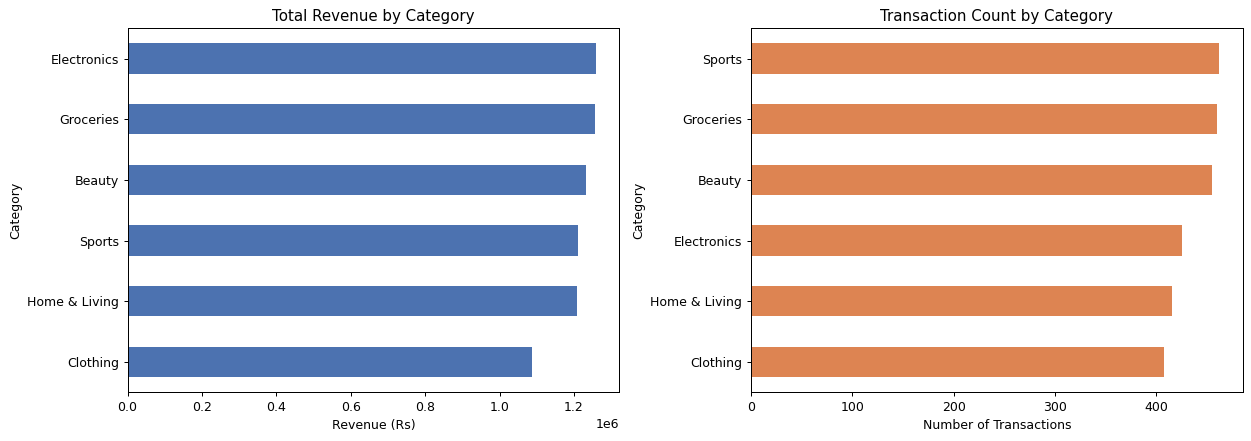

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_revenue['Total Revenue'].sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Revenue (Rs)')

category_revenue['Transaction Count'].sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Transaction Count by Category')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()


### 3.2 Sales Trend Over Time

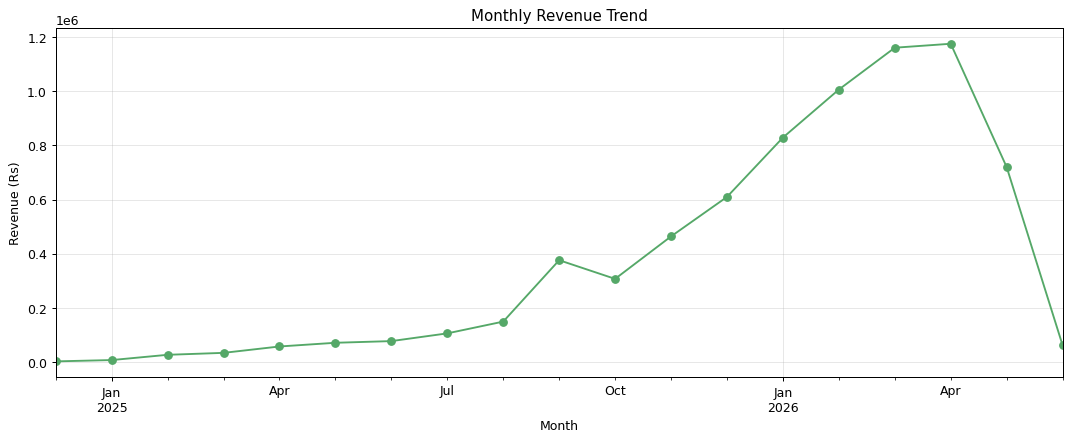

In [15]:
monthly_sales = df.set_index('Date').resample('ME')['Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker='o', color='#55A868')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 Distribution of Transaction Amounts

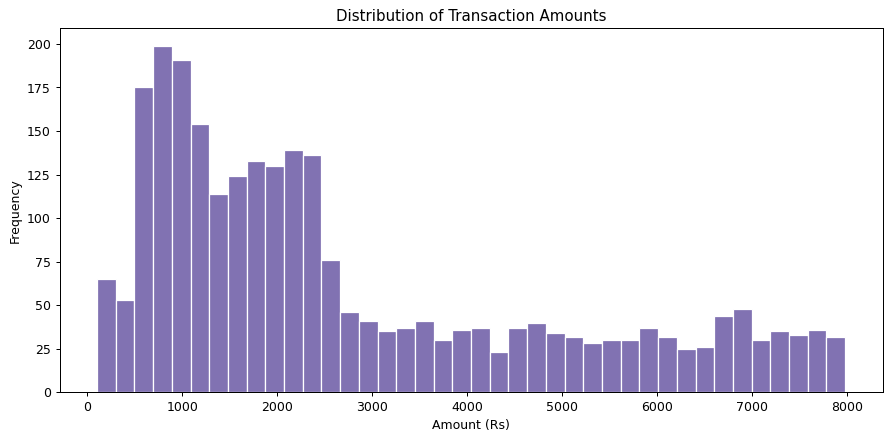

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df['Amount'], bins=40, color='#8172B2', edgecolor='white')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (Rs)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### 3.4 Transactions per Customer

Average transactions per customer: 8.7
Max transactions by a single customer: 29


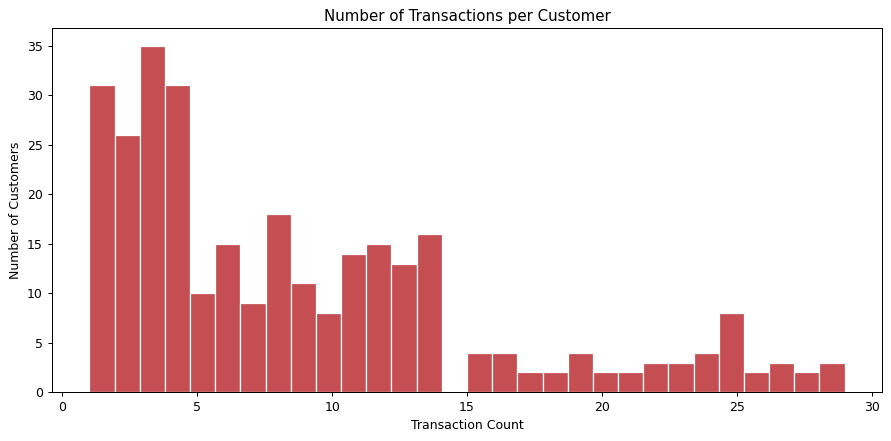

In [19]:
txn_per_customer = df.groupby('CustomerID').size()

plt.figure(figsize=(10, 5))
plt.hist(txn_per_customer, bins=30, color='#C44E52', edgecolor='white')
plt.title('Number of Transactions per Customer')
plt.xlabel('Transaction Count')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(f"Average transactions per customer: {txn_per_customer.mean():.1f}")
print(f"Max transactions by a single customer: {txn_per_customer.max()}")


### 3.5 Top 10 Customers by Total Spend

In [21]:
top_customers = df.groupby('CustomerID')['Amount'].sum().sort_values(ascending=False).head(10)
top_customers.to_frame('Total Spend')


## 4. Key Findings

- Revenue is spread across all six product categories, with some categories generating
  noticeably higher totals due to higher average transaction values rather than volume.
- Monthly revenue shows a general upward pattern with month-to-month fluctuation,
  consistent with a growing but seasonal customer base.
- Transaction amounts are right-skewed: most purchases are modest, with a smaller number
  of high-value transactions pulling the average up.
- Transaction frequency per customer varies widely — a small group of very active,
  frequent buyers exists alongside many low-frequency, occasional customers. This hints
  at natural customer segments, which we explore formally with K-Means clustering in
  `customer_segmentation.ipynb`.

**Next step:** Proceed to `customer_segmentation.ipynb` for RFM analysis and K-Means
customer segmentation.
